# Segmentation Presentation Assets

`data/doraemong.jpeg` 기준으로 segmentation 발표에 필요한 이미지만 생성합니다. 결과는 `presentation_segmentation/` 폴더에 저장됩니다.

In [1]:
import os
import sys
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np

sys.path.append("src")
import importlib
import coloringbook_utils as coloringbook_utils
importlib.reload(coloringbook_utils)
from coloringbook_utils import *

IMAGE_PATH = "data/doraemong.jpeg"
OUT_DIR = Path("presentation_segmentation")
OUT_DIR.mkdir(exist_ok=True)

K = 30
OBJECT_MIN_AREA = 260
OBJECT_CLOSE_KERNEL = 5
LINE_THICKNESS = 1
MIN_REGION_AREA = 160
SIMPLIFY_DIAMETER = 9
SIMPLIFY_SIGMA_COLOR = 90
SIMPLIFY_SIGMA_SPACE = 90
DETAIL_CANNY_LOW = 90
DETAIL_CANNY_HIGH = 200
DETAIL_MIN_AREA = 3
DETAIL_MAX_AREA = 1200
DARK_DETAIL_THRESHOLD = 70
DARK_DETAIL_MIN_AREA = 5
DARK_DETAIL_MAX_AREA = 900

image = load_image(IMAGE_PATH)
print(f"Loaded {IMAGE_PATH}: {image.shape}")

Loaded data/doraemong.jpeg: (512, 519, 3)


In [2]:
def object_first_edges(label_map, min_area=260, close_kernel=5, thickness=1):
    labels = np.asarray(label_map, dtype=np.int32)
    edge = np.zeros(labels.shape, dtype=np.uint8)
    kernel = np.ones((close_kernel, close_kernel), np.uint8)
    for label_id in np.unique(labels):
        mask = (labels == label_id).astype(np.uint8) * 255
        mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=1)
        mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, np.ones((3, 3), np.uint8), iterations=1)
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        for contour in contours:
            if cv2.contourArea(contour) >= min_area:
                cv2.drawContours(edge, [contour], -1, 255, thickness, cv2.LINE_8)
    return edge


def thin_binary_edges(edges):
    img = (edges > 0).astype(np.uint8)
    changed = True
    while changed:
        changed = False
        for step in (0, 1):
            padded = np.pad(img, 1, mode="constant")
            marker = np.zeros_like(img)
            for y in range(1, padded.shape[0] - 1):
                for x in range(1, padded.shape[1] - 1):
                    if padded[y, x] == 0:
                        continue
                    p2 = padded[y - 1, x]
                    p3 = padded[y - 1, x + 1]
                    p4 = padded[y, x + 1]
                    p5 = padded[y + 1, x + 1]
                    p6 = padded[y + 1, x]
                    p7 = padded[y + 1, x - 1]
                    p8 = padded[y, x - 1]
                    p9 = padded[y - 1, x - 1]
                    neighbors = [p2, p3, p4, p5, p6, p7, p8, p9]
                    count = sum(neighbors)
                    transitions = sum((neighbors[i] == 0 and neighbors[(i + 1) % 8] == 1) for i in range(8))
                    if not (2 <= count <= 6 and transitions == 1):
                        continue
                    if step == 0:
                        if p2 * p4 * p6 == 0 and p4 * p6 * p8 == 0:
                            marker[y - 1, x - 1] = 1
                    else:
                        if p2 * p4 * p8 == 0 and p2 * p6 * p8 == 0:
                            marker[y - 1, x - 1] = 1
            if np.any(marker):
                img[marker == 1] = 0
                changed = True
    return (img * 255).astype(np.uint8)


def detail_expression_edges(image, object_edges):
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    detail = cv2.Canny(gray, DETAIL_CANNY_LOW, DETAIL_CANNY_HIGH)
    detail = cv2.bitwise_and(detail, cv2.bitwise_not(object_edges))
    n_labels, labels, stats, _ = cv2.connectedComponentsWithStats(detail, 8)
    filtered_edges = np.zeros_like(detail)
    for i in range(1, n_labels):
        area = int(stats[i, cv2.CC_STAT_AREA])
        if DETAIL_MIN_AREA <= area <= DETAIL_MAX_AREA:
            filtered_edges[labels == i] = 255

    dark = (gray < DARK_DETAIL_THRESHOLD).astype(np.uint8) * 255
    n_labels, labels, stats, _ = cv2.connectedComponentsWithStats(dark, 8)
    filtered_dark = np.zeros_like(dark)
    for i in range(1, n_labels):
        area = int(stats[i, cv2.CC_STAT_AREA])
        if DARK_DETAIL_MIN_AREA <= area <= DARK_DETAIL_MAX_AREA:
            filtered_dark[labels == i] = 255
    return cv2.bitwise_or(filtered_edges, filtered_dark)


def border_connected_region_ids(region_map):
    border_ids = np.concatenate([region_map[0, :], region_map[-1, :], region_map[:, 0], region_map[:, -1]])
    return set(int(v) for v in np.unique(border_ids) if int(v) > 0)


def best_label_point(region_map, region_id, bbox):
    x, y, w, h = bbox
    component = (region_map[y:y + h, x:x + w] == region_id).astype(np.uint8)
    if component.size == 0 or np.count_nonzero(component) == 0:
        return x + w / 2, y + h / 2
    dist = cv2.distanceTransform(component, cv2.DIST_L2, 5)
    _, _, _, max_loc = cv2.minMaxLoc(dist)
    return x + max_loc[0], y + max_loc[1]


def main_object_mask(source_image):
    border = np.concatenate([source_image[0, :, :], source_image[-1, :, :], source_image[:, 0, :], source_image[:, -1, :]], axis=0)
    bg = np.median(border.reshape(-1, 3), axis=0)
    diff = np.linalg.norm(source_image.astype(np.float32) - bg.astype(np.float32), axis=2)
    gray_src = cv2.cvtColor(source_image, cv2.COLOR_RGB2GRAY)
    seed = ((diff > 28) | (gray_src < 120)).astype(np.uint8) * 255
    seed = cv2.morphologyEx(seed, cv2.MORPH_OPEN, np.ones((3, 3), np.uint8), iterations=1)
    seed = cv2.morphologyEx(seed, cv2.MORPH_CLOSE, np.ones((17, 17), np.uint8), iterations=2)
    seed = cv2.dilate(seed, np.ones((5, 5), np.uint8), iterations=2)
    n_labels, labels, stats, _ = cv2.connectedComponentsWithStats(seed, 8)
    if n_labels <= 1:
        return seed
    largest = 1 + int(np.argmax(stats[1:, cv2.CC_STAT_AREA]))
    mask = (labels == largest).astype(np.uint8) * 255
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    filled = np.zeros_like(mask)
    if contours:
        cv2.drawContours(filled, contours, -1, 255, -1)
        filled = cv2.morphologyEx(filled, cv2.MORPH_CLOSE, np.ones((21, 21), np.uint8), iterations=1)
        return filled
    return mask


def draw_numbered(line_image, detail_edges, regions, region_map, background_ids, object_mask=None, use_mask=True):
    gray = cv2.cvtColor(line_image, cv2.COLOR_RGB2GRAY) if line_image.ndim == 3 else line_image
    keep = np.ones_like(gray, dtype=bool) if object_mask is None or not use_mask else object_mask > 0
    edge_mask = ((gray < 128) | (detail_edges > 0)) & keep
    canvas = np.full((gray.shape[0], gray.shape[1], 3), 255, dtype=np.uint8)
    canvas[edge_mask] = 185
    font = cv2.FONT_HERSHEY_SIMPLEX
    for region in sorted(regions, key=lambda r: r["area"], reverse=True):
        region_id = int(region["id"])
        if region_id in background_ids or region["area"] < MIN_REGION_AREA:
            continue
        pixels = region_map == region_id
        if use_mask and object_mask is not None:
            overlap = np.count_nonzero(pixels & keep)
            if overlap == 0 or overlap / max(1, int(region["area"])) < 0.45:
                continue
        text = str(region.get("color_id", region_id))
        cx, cy = best_label_point(region_map, region_id, region["bbox"])
        (tw, th), _ = cv2.getTextSize(text, font, 0.42, 1)
        x0, y0, w, h = region["bbox"]
        x = int(np.clip(cx - tw / 2, x0 + 1, max(x0 + 1, x0 + w - tw - 1)))
        y = int(np.clip(cy + th / 2, y0 + th + 1, max(y0 + th + 1, y0 + h - 1)))
        cv2.putText(canvas, text, (x, y), font, 0.42, (155, 155, 155), 1, cv2.LINE_AA)
    return canvas


def save_named(name, img):
    path = OUT_DIR / name
    save_image_rgb(str(path), img)
    return path


def save_compare(name, items, cols=2, figsize=(10, 5), cmap=None):
    path = OUT_DIR / name
    show_images(items, cols=cols, figsize=figsize, cmap=cmap, save_path=str(path))
    return path

In [3]:
# Segmentation용 결과 생성
simplified = cv2.bilateralFilter(image, SIMPLIFY_DIAMETER, SIMPLIFY_SIGMA_COLOR, SIMPLIFY_SIGMA_SPACE)
kmeans_img, kmeans_palette, kmeans_labels = kmeans_quantization_with_labels(simplified, K)

object_raw = object_first_edges(kmeans_labels, min_area=OBJECT_MIN_AREA, close_kernel=OBJECT_CLOSE_KERNEL, thickness=LINE_THICKNESS)
object_seg_clean = clean_edges(object_raw, open_iter=0, close_iter=1, thickness=2)
object_final_clean = thin_binary_edges(object_seg_clean)
object_line = coloring_line_image(object_final_clean)
segmentation_line = coloring_line_image(object_seg_clean)
detail_edges = detail_expression_edges(image, object_final_clean)
detail_line = coloring_line_image(detail_edges)
line_with_detail = object_line.copy()
line_with_detail[detail_edges > 0] = 0

region_map, regions = segment_connected_components(segmentation_line, MIN_REGION_AREA)
background_color = estimate_background_color(kmeans_img)
regions = assign_region_color_numbers(
    regions,
    region_map,
    kmeans_labels,
    kmeans_palette,
    background_color=background_color,
    background_color_threshold=16,
    merge_background_similar=True,
)
background_ids = border_connected_region_ids(region_map)
for region in regions:
    if int(region["id"]) in background_ids:
        region["is_background"] = True

region_preview = color_region_preview(region_map)
obj_mask = main_object_mask(simplified)
mask_preview = np.full_like(image, 255)
mask_preview[obj_mask > 0] = image[obj_mask > 0]

before_noisy = draw_numbered(object_line, detail_edges, regions, region_map, background_ids, object_mask=obj_mask, use_mask=False)
after_clean = draw_numbered(object_line, detail_edges, regions, region_map, background_ids, object_mask=obj_mask, use_mask=True)

colored_by_labels = np.full_like(simplified, 255)
for region in regions:
    color = region.get("color_rgb")
    if color is not None:
        colored_by_labels[region_map == region["id"]] = np.array(color, dtype=np.uint8)
colored_by_labels[segmentation_line < 128] = 0
colored_by_labels_with_detail = colored_by_labels.copy()
colored_by_labels_with_detail[detail_edges > 0] = 0
colored_numbered = label_regions(colored_by_labels_with_detail, regions, font_scale=0.65, region_map=region_map, skip_background=True)

print(f"total_regions={len(regions)}")
print(f"background_regions={len(background_ids)}")
print(f"numbered_regions={sum(1 for r in regions if not r.get('is_background', False) and r['area'] >= MIN_REGION_AREA)}")

total_regions=80
background_regions=8
numbered_regions=13


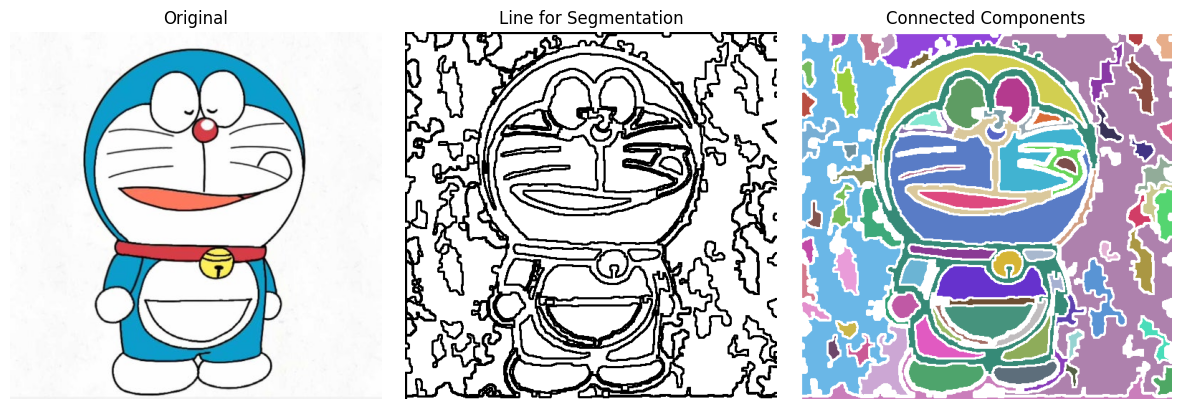

WindowsPath('presentation_segmentation/s1_segmentation_problem_overview.png')

In [4]:
# Slide S1: Segmentation 문제 정의
save_named("s1_original.png", image)
save_named("s1_segmentation_line_input.png", segmentation_line)
save_named("s1_region_preview.png", region_preview)
save_compare(
    "s1_segmentation_problem_overview.png",
    [("Original", image), ("Line for Segmentation", segmentation_line), ("Connected Components", region_preview)],
    cols=3,
    figsize=(12, 4),
    cmap="gray",
)

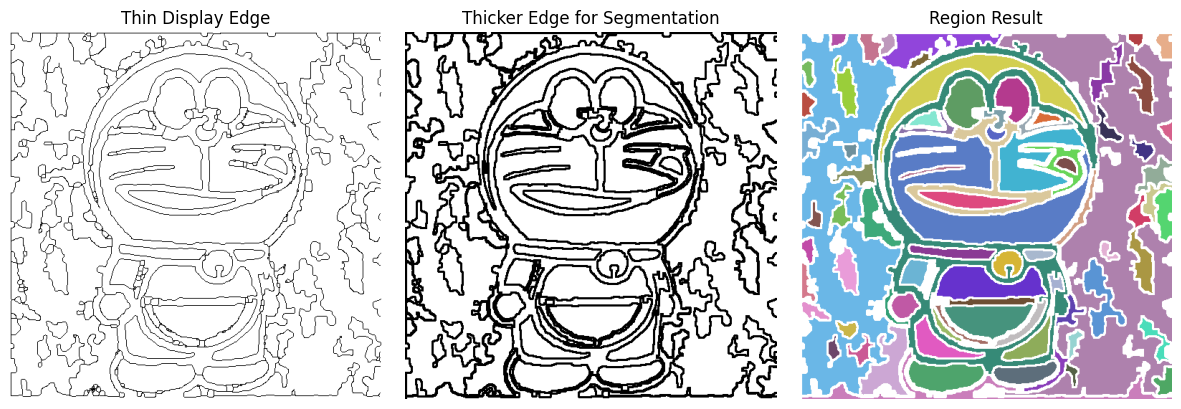

WindowsPath('presentation_segmentation/s2_closed_region_tradeoff.png')

In [5]:
# Slide S2: 닫힌 영역 생성 trade-off
save_named("s2_thin_display_edge.png", object_line)
save_named("s2_thicker_segmentation_edge.png", segmentation_line)
save_compare(
    "s2_closed_region_tradeoff.png",
    [("Thin Display Edge", object_line), ("Thicker Edge for Segmentation", segmentation_line), ("Region Result", region_preview)],
    cols=3,
    figsize=(12, 4),
    cmap="gray",
)

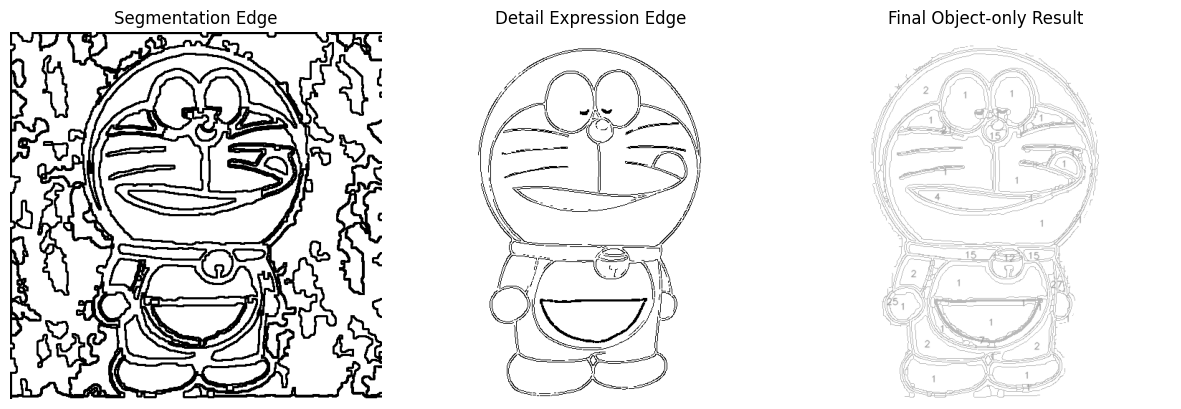

WindowsPath('presentation_segmentation/s3_segmentation_vs_detail_edge.png')

In [6]:
# Slide S3: Detail edge를 segmentation에서 분리
save_named("s3_segmentation_edge.png", segmentation_line)
save_named("s3_detail_expression_edge.png", detail_line)
save_named("s3_line_with_detail.png", line_with_detail)
save_compare(
    "s3_segmentation_vs_detail_edge.png",
    [("Segmentation Edge", segmentation_line), ("Detail Expression Edge", detail_line), ("Final Object-only Result", after_clean)],
    cols=3,
    figsize=(12, 4),
    cmap="gray",
)

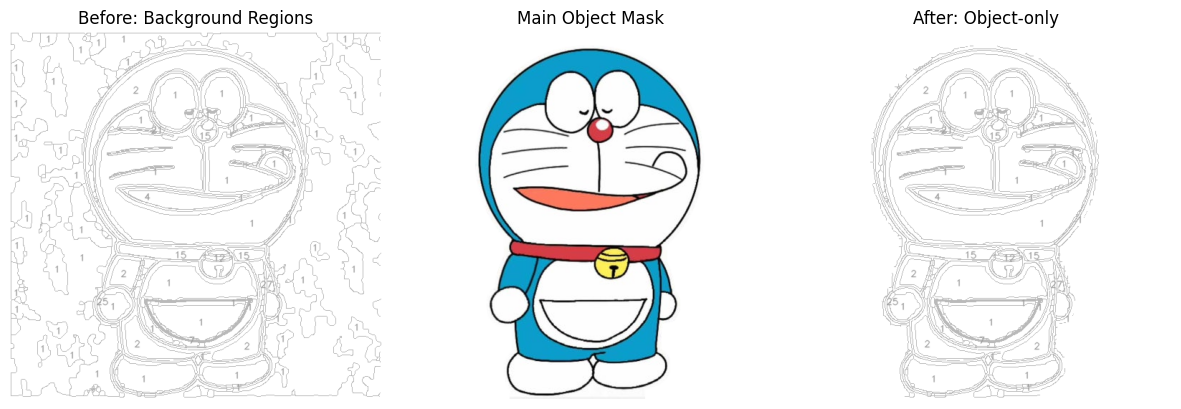

WindowsPath('presentation_segmentation/s4_background_tradeoff_before_after.png')

In [7]:
# Slide S4: 배경 처리 trade-off
save_named("s4_object_mask_preview.png", mask_preview)
save_named("s4_before_background_noise.png", before_noisy)
save_named("s4_after_object_only.png", after_clean)
save_compare(
    "s4_background_tradeoff_before_after.png",
    [("Before: Background Regions", before_noisy), ("Main Object Mask", mask_preview), ("After: Object-only", after_clean)],
    cols=3,
    figsize=(12, 4),
)

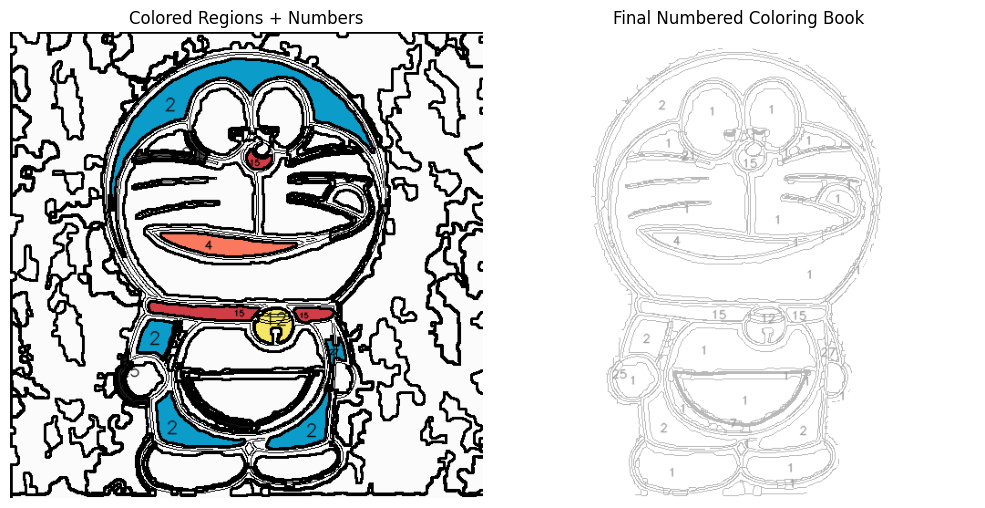

WindowsPath('presentation_segmentation/s5_numbering_result.png')

In [8]:
# Slide S5: 번호화 결과
save_named("s5_colored_regions_numbered.png", colored_numbered)
save_named("s5_final_numbered_coloringbook.png", after_clean)
save_compare(
    "s5_numbering_result.png",
    [("Colored Regions + Numbers", colored_numbered), ("Final Numbered Coloring Book", after_clean)],
    cols=2,
    figsize=(10, 5),
)

In [9]:
print("Saved segmentation presentation assets:")
for p in sorted(OUT_DIR.glob("*.png")):
    print(p)

Saved segmentation presentation assets:
presentation_segmentation\s1_original.png
presentation_segmentation\s1_region_preview.png
presentation_segmentation\s1_segmentation_line_input.png
presentation_segmentation\s1_segmentation_problem_overview.png
presentation_segmentation\s2_closed_region_tradeoff.png
presentation_segmentation\s2_thicker_segmentation_edge.png
presentation_segmentation\s2_thin_display_edge.png
presentation_segmentation\s3_detail_expression_edge.png
presentation_segmentation\s3_line_with_detail.png
presentation_segmentation\s3_segmentation_edge.png
presentation_segmentation\s3_segmentation_vs_detail_edge.png
presentation_segmentation\s4_after_object_only.png
presentation_segmentation\s4_background_tradeoff_before_after.png
presentation_segmentation\s4_before_background_noise.png
presentation_segmentation\s4_object_mask_preview.png
presentation_segmentation\s5_colored_regions_numbered.png
presentation_segmentation\s5_final_numbered_coloringbook.png
presentation_segment